<a href="https://colab.research.google.com/github/eric56427/er1c/blob/main/Project_3_Bayesian_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 3 - Bayesian Network Inference
## Machine Learning Spring 2026

This notebook implements a Car Diagnosis Bayesian Network using NetworkX, attaches probability tables to each node, visualizes the network, and performs inference for requirements R1–R3.

In [ ]:
# https://colab.research.google.com/drive/1pdN_Ul9VEiLmmJHJpYBMrUB0ArHzSLFv?usp=sharing#scrollTo=PZThOClguKuK

---
## R1: Build and Visualize the Bayesian Network
Create the directed graph with all 11 nodes, edges showing directionality, and probability tables attached to each node.

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph for the Bayesian Network
G = nx.DiGraph()

In [ ]:
# ============================================================
# Add all 11 nodes with their probability tables
# ============================================================

# 1. Battery age (root node) - P(ba)
G.add_node("ba", ba_y=0.2, ba_n=0.8)

# 2. Alternator broken (root node) - P(ab)
G.add_node("ab", ab_y=0.1, ab_n=0.9)

# 3. Fanbelt broken (root node) - P(fb)
G.add_node("fb", fb_y=0.3, fb_n=0.7)

# 4. Battery dead - P(bd | ba)
G.add_node("bd",
    ba_y_bd_y=0.7, ba_y_bd_n=0.3,
    ba_n_bd_y=0.2, ba_n_bd_n=0.8
)

# 5. No charging - P(nc | ab, fb)
G.add_node("nc",
    ab_y_fb_y_nc_y=0.75, ab_y_fb_y_nc_n=0.25,
    ab_y_fb_n_nc_y=0.4,  ab_y_fb_n_nc_n=0.6,
    ab_n_fb_y_nc_y=0.6,  ab_n_fb_y_nc_n=0.4,
    ab_n_fb_n_nc_y=0.1,  ab_n_fb_n_nc_n=0.9
)

# 6. Battery flat - P(bf | bd, nc)
G.add_node("bf",
    bd_y_nc_y_bf_y=0.95, bd_y_nc_y_bf_n=0.05,
    bd_y_nc_n_bf_y=0.85, bd_y_nc_n_bf_n=0.15,
    bd_n_nc_y_bf_y=0.8,  bd_n_nc_y_bf_n=0.2,
    bd_n_nc_n_bf_y=0.1,  bd_n_nc_n_bf_n=0.9
)

# 7. No oil (root node) - P(no)
G.add_node("no", no_y=0.05, no_n=0.95)

# 8. Lights - P(l | bf)
G.add_node("l",
    bf_y_l_y=0.05, bf_y_l_n=0.95,
    bf_n_l_y=0.9,  bf_n_l_n=0.1
)

# 9. Gas gauge - P(gg | bf)
G.add_node("gg",
    bf_y_gg_y=0.1,  bf_y_gg_n=0.9,
    bf_n_gg_y=0.95, bf_n_gg_n=0.05
)

# 10. Dipstick level - P(dl | no)
G.add_node("dl",
    no_y_dl_y=0.95, no_y_dl_n=0.05,
    no_n_dl_y=0.3,  no_n_dl_n=0.7
)

# 11. Car won't start - P(cws | bf, no)
#     Note: The discussion document has typos in the _n rows.
#     We use the _y values as given and compute _n as complements.
G.add_node("cws",
    bf_y_no_y_cws_y=0.90, bf_y_no_y_cws_n=0.10,
    bf_y_no_n_cws_y=0.90, bf_y_no_n_cws_n=0.10,
    bf_n_no_y_cws_y=0.30, bf_n_no_y_cws_n=0.70,
    bf_n_no_n_cws_y=0.15, bf_n_no_n_cws_n=0.85
)

print("Nodes:", list(G.nodes))
print(f"Total nodes: {G.number_of_nodes()}")

Nodes: ['ba', 'ab', 'fb', 'bd', 'nc', 'bf', 'no', 'l', 'gg', 'dl', 'cws']
Total nodes: 11


In [ ]:
# ============================================================
# Add all directed edges (parent -> child)
# ============================================================

G.add_edges_from([
    ("ba", "bd"),    # battery age -> battery dead
    ("ab", "nc"),    # alternator broken -> no charging
    ("fb", "nc"),    # fanbelt broken -> no charging
    ("bd", "bf"),    # battery dead -> battery flat
    ("nc", "bf"),    # no charging -> battery flat
    ("bf", "l"),     # battery flat -> lights
    ("bf", "gg"),    # battery flat -> gas gauge
    ("bf", "cws"),   # battery flat -> car won't start
    ("no", "cws"),   # no oil -> car won't start
    ("no", "dl"),    # no oil -> dipstick
])

print("Edges:", list(G.edges))
print(f"Total edges: {G.number_of_edges()}")

Edges: [('ba', 'bd'), ('ab', 'nc'), ('fb', 'nc'), ('bd', 'bf'), ('nc', 'bf'), ('bf', 'l'), ('bf', 'gg'), ('bf', 'cws'), ('no', 'cws'), ('no', 'dl')]
Total edges: 10


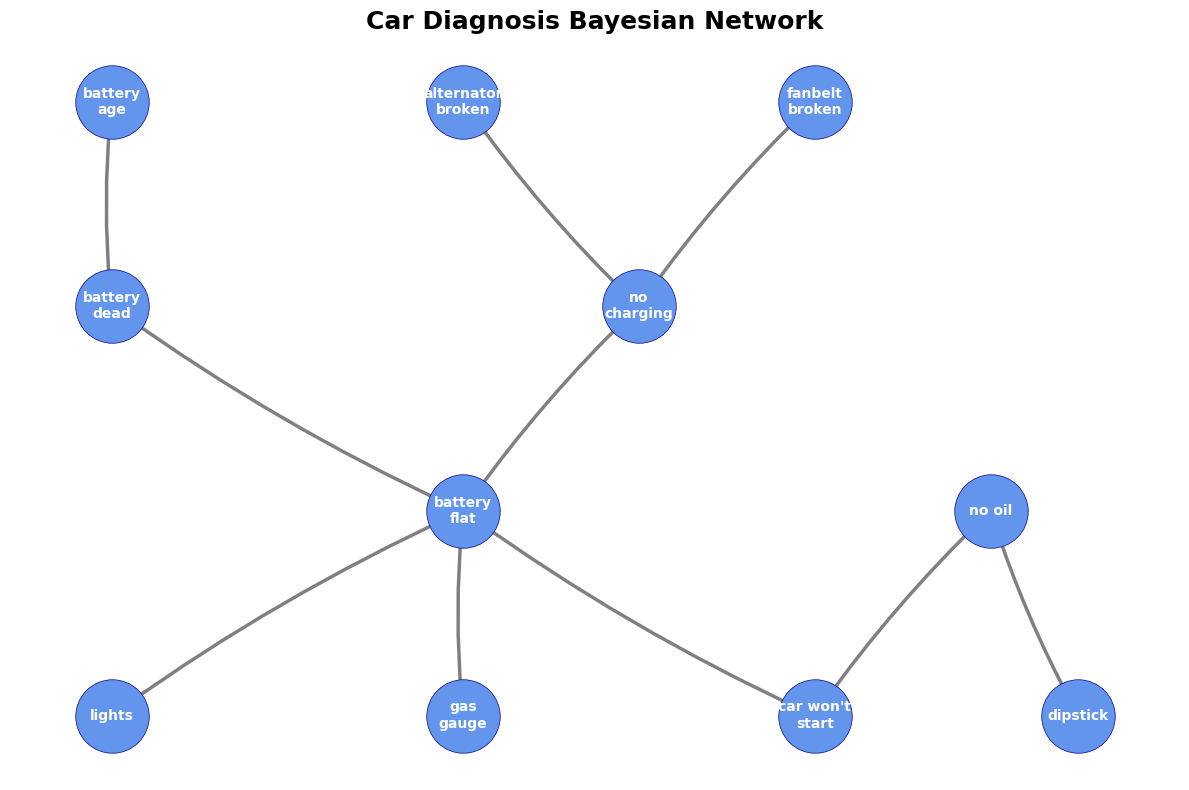

In [ ]:
# ============================================================
# Visualize the Bayesian Network
# ============================================================

# Define a custom layout that matches the diagram from the project document
pos = {
    "ba":  (-2.0,  3.0),   # battery age (top-left)
    "ab":  ( 0.0,  3.0),   # alternator broken (top-center)
    "fb":  ( 2.0,  3.0),   # fanbelt broken (top-right)
    "bd":  (-2.0,  1.5),   # battery dead
    "nc":  ( 1.0,  1.5),   # no charging
    "bf":  ( 0.0,  0.0),   # battery flat (center)
    "no":  ( 3.0,  0.0),   # no oil
    "l":   (-2.0, -1.5),   # lights
    "gg":  ( 0.0, -1.5),   # gas gauge
    "cws": ( 2.0, -1.5),   # car won't start
    "dl":  ( 3.5, -1.5),   # dipstick
}

# Full descriptive labels for display
labels = {
    "ba":  "battery\nage",
    "ab":  "alternator\nbroken",
    "fb":  "fanbelt\nbroken",
    "bd":  "battery\ndead",
    "nc":  "no\ncharging",
    "bf":  "battery\nflat",
    "no":  "no oil",
    "l":   "lights",
    "gg":  "gas\ngauge",
    "cws": "car won't\nstart",
    "dl":  "dipstick",
}

plt.figure(figsize=(12, 8))

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=2800, node_color='cornflowerblue',
                       linewidths=0.5, edgecolors='darkblue')

# Draw directed edges with arrows
nx.draw_networkx_edges(G, pos, edgelist=G.edges, width=2.5,
                       arrowstyle='->', arrowsize=30,
                       edge_color='gray', connectionstyle='arc3,rad=0.05')

# Draw labels
nx.draw_networkx_labels(G, pos, labels=labels, font_size=10,
                        font_color='white', font_weight='bold')

plt.title("Car Diagnosis Bayesian Network", fontsize=18, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

---
## Helper Functions for Probability Lookups
These functions extract conditional probabilities from the node attribute tables stored in the graph.

In [ ]:
# ============================================================
# Helper functions to look up probabilities from the CPTs
# Convention: 1 = "yes" (_y), 0 = "no" (_n)
# ============================================================

def yn(val):
    """Convert 0/1 to 'n'/'y' string suffix."""
    return 'y' if val == 1 else 'n'


def P_ba(ba):
    """P(battery_age = ba)"""
    return G.nodes['ba'][f'ba_{yn(ba)}']


def P_ab(ab):
    """P(alternator_broken = ab)"""
    return G.nodes['ab'][f'ab_{yn(ab)}']


def P_fb(fb):
    """P(fanbelt_broken = fb)"""
    return G.nodes['fb'][f'fb_{yn(fb)}']


def P_bd_given_ba(bd, ba):
    """P(battery_dead = bd | battery_age = ba)"""
    return G.nodes['bd'][f'ba_{yn(ba)}_bd_{yn(bd)}']


def P_nc_given_ab_fb(nc, ab, fb):
    """P(no_charging = nc | alternator_broken = ab, fanbelt_broken = fb)"""
    return G.nodes['nc'][f'ab_{yn(ab)}_fb_{yn(fb)}_nc_{yn(nc)}']


def P_bf_given_bd_nc(bf, bd, nc):
    """P(battery_flat = bf | battery_dead = bd, no_charging = nc)"""
    return G.nodes['bf'][f'bd_{yn(bd)}_nc_{yn(nc)}_bf_{yn(bf)}']


def P_no(no):
    """P(no_oil = no)"""
    return G.nodes['no'][f'no_{yn(no)}']


def P_cws_given_bf_no(cws, bf, no):
    """P(car_wont_start = cws | battery_flat = bf, no_oil = no)"""
    return G.nodes['cws'][f'bf_{yn(bf)}_no_{yn(no)}_cws_{yn(cws)}']


def P_l_given_bf(l, bf):
    """P(lights = l | battery_flat = bf)"""
    return G.nodes['l'][f'bf_{yn(bf)}_l_{yn(l)}']


def P_gg_given_bf(gg, bf):
    """P(gas_gauge = gg | battery_flat = bf)"""
    return G.nodes['gg'][f'bf_{yn(bf)}_gg_{yn(gg)}']


def P_dl_given_no(dl, no):
    """P(dipstick = dl | no_oil = no)"""
    return G.nodes['dl'][f'no_{yn(no)}_dl_{yn(dl)}']


# Quick verification: print a few probabilities
print("P(ba=y) =", P_ba(1))
print("P(bd=y | ba=y) =", P_bd_given_ba(1, 1))
print("P(nc=y | ab=y, fb=y) =", P_nc_given_ab_fb(1, 1, 1))
print("P(bf=y | bd=y, nc=y) =", P_bf_given_bd_nc(1, 1, 1))
print("P(cws=y | bf=y, no=y) =", P_cws_given_bf_no(1, 1, 1))

P(ba=y) = 0.2
P(bd=y | ba=y) = 0.7
P(nc=y | ab=y, fb=y) = 0.75
P(bf=y | bd=y, nc=y) = 0.95
P(cws=y | bf=y, no=y) = 0.9


---
## R2: Compute P(+cws | +fb)

**Goal:** Probability that the car won't start given that the fanbelt is broken.

### Approach — Markov Blanket & Variable Elimination

From the discussion document:
- M(cws) = {cws, no, bf}  (parents of cws)
- M(fb) = {fb, nc, ab}    (child nc and co-parent ab)
- M(R2) = {cws, no, bf, fb, nc, ab}

Using the definition of conditional probability:

$$P(+cws|+fb) = \frac{P(+cws, +fb)}{P(+fb)}$$

Since $P(+fb) = 0.3$ is given directly, we need to compute $P(+cws, +fb)$.

By the chain rule / variable elimination over the full network (marginalizing out leaf nodes l, gg, dl whose CPTs sum to 1):

$$P(+cws, +fb) = P(+fb) \times \sum_{ba, ab, bd, nc, bf, no} P(ba) \cdot P(ab) \cdot P(bd|ba) \cdot P(nc|ab, +fb) \cdot P(bf|bd, nc) \cdot P(no) \cdot P(+cws|bf, no)$$

Therefore:

$$P(+cws|+fb) = \sum_{ba, ab, bd, nc, bf, no} P(ba) \cdot P(ab) \cdot P(bd|ba) \cdot P(nc|ab, +fb) \cdot P(bf|bd, nc) \cdot P(no) \cdot P(+cws|bf, no)$$

In [ ]:
# ============================================================
# R2: Compute P(+cws | +fb)
# ============================================================
# Evidence: fb = 1 (fanbelt is broken)
# Query:    cws = 1 (car won't start)
#
# Free variables to sum over: ba, ab, bd, nc, bf, no  (each in {0, 1})
# ============================================================

fb_evidence = 1  # fanbelt is broken

P_cws_and_fb = 0.0

for ba in [0, 1]:
    for ab in [0, 1]:
        for bd in [0, 1]:
            for nc in [0, 1]:
                for bf in [0, 1]:
                    for no in [0, 1]:
                        term = (
                            P_ba(ba)
                            * P_ab(ab)
                            * P_fb(fb_evidence)         # P(+fb) = 0.3
                            * P_bd_given_ba(bd, ba)
                            * P_nc_given_ab_fb(nc, ab, fb_evidence)  # conditioned on +fb
                            * P_bf_given_bd_nc(bf, bd, nc)
                            * P_no(no)
                            * P_cws_given_bf_no(1, bf, no)          # cws = 1 (+cws)
                        )
                        P_cws_and_fb += term

# P(+fb) is just the prior
P_fb_pos = P_fb(1)  # 0.3

# Apply Bayes' rule: P(+cws | +fb) = P(+cws, +fb) / P(+fb)
P_cws_given_fb = P_cws_and_fb / P_fb_pos

print("="*50)
print("R2: P(+cws | +fb)")
print("="*50)
print(f"P(+cws, +fb) = {P_cws_and_fb:.6f}")
print(f"P(+fb)       = {P_fb_pos:.6f}")
print(f"P(+cws|+fb)  = {P_cws_given_fb:.6f}")
print("="*50)

R2: P(+cws | +fb)
P(+cws, +fb) = 0.190879
P(+fb)       = 0.300000
P(+cws|+fb)  = 0.636264


---
## R3: Compute P(+cws | +ba)

**Goal:** Probability that the car won't start given that the battery is aged.

### Approach

Using the same methodology:

$$P(+cws|+ba) = \frac{P(+cws, +ba)}{P(+ba)}$$

Since $P(+ba) = 0.2$, we compute:

$$P(+cws, +ba) = P(+ba) \times \sum_{ab, fb, bd, nc, bf, no} P(ab) \cdot P(fb) \cdot P(bd|+ba) \cdot P(nc|ab, fb) \cdot P(bf|bd, nc) \cdot P(no) \cdot P(+cws|bf, no)$$

Therefore:

$$P(+cws|+ba) = \sum_{ab, fb, bd, nc, bf, no} P(ab) \cdot P(fb) \cdot P(bd|+ba) \cdot P(nc|ab, fb) \cdot P(bf|bd, nc) \cdot P(no) \cdot P(+cws|bf, no)$$

In [ ]:
# ============================================================
# R3: Compute P(+cws | +ba)
# ============================================================
# Evidence: ba = 1 (battery is aged)
# Query:    cws = 1 (car won't start)
#
# Free variables to sum over: ab, fb, bd, nc, bf, no  (each in {0, 1})
# ============================================================

ba_evidence = 1  # battery is aged

P_cws_and_ba = 0.0

for ab in [0, 1]:
    for fb in [0, 1]:
        for bd in [0, 1]:
            for nc in [0, 1]:
                for bf in [0, 1]:
                    for no in [0, 1]:
                        term = (
                            P_ba(ba_evidence)              # P(+ba) = 0.2
                            * P_ab(ab)
                            * P_fb(fb)
                            * P_bd_given_ba(bd, ba_evidence)  # conditioned on +ba
                            * P_nc_given_ab_fb(nc, ab, fb)
                            * P_bf_given_bd_nc(bf, bd, nc)
                            * P_no(no)
                            * P_cws_given_bf_no(1, bf, no)    # cws = 1 (+cws)
                        )
                        P_cws_and_ba += term

# P(+ba) is just the prior
P_ba_pos = P_ba(1)  # 0.2

# Apply Bayes' rule: P(+cws | +ba) = P(+cws, +ba) / P(+ba)
P_cws_given_ba = P_cws_and_ba / P_ba_pos

print("="*50)
print("R3: P(+cws | +ba)")
print("="*50)
print(f"P(+cws, +ba) = {P_cws_and_ba:.6f}")
print(f"P(+ba)       = {P_ba_pos:.6f}")
print(f"P(+cws|+ba)  = {P_cws_given_ba:.6f}")
print("="*50)

R3: P(+cws | +ba)
P(+cws, +ba) = 0.135768
P(+ba)       = 0.200000
P(+cws|+ba)  = 0.678839


---
## Summary of Results

In [ ]:
print("\n" + "="*55)
print("        SUMMARY OF INFERENCE RESULTS")
print("="*55)
print(f"  R2:  P(+cws | +fb) = {P_cws_given_fb:.6f}")
print(f"  R3:  P(+cws | +ba) = {P_cws_given_ba:.6f}")
print("="*55)
print("\nInterpretation:")
print(f"  - If the fanbelt is broken, there is a {P_cws_given_fb*100:.2f}%")
print(f"    chance the car won't start.")
print(f"  - If the battery is aged, there is a {P_cws_given_ba*100:.2f}%")
print(f"    chance the car won't start.")


        SUMMARY OF INFERENCE RESULTS
  R2:  P(+cws | +fb) = 0.636264
  R3:  P(+cws | +ba) = 0.678839

Interpretation:
  - If the fanbelt is broken, there is a 63.63%
    chance the car won't start.
  - If the battery is aged, there is a 67.88%
    chance the car won't start.
